In [1]:
import sys
sys.path.append('../src')

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm

from plotnine import *
theme_set(theme_bw())

import numpyro
from numpyro_utils import run_inference_mcmc
from models import BRCStratified
numpyro.set_host_device_count(4)

import arviz as az

In [2]:
# Read data (pikled)
with open('../data/sim/stratified.pkl', 'rb') as f:
    data = pickle.load(f)

# Prepare data
data['data']['X_a'] = data['data']['subgroup']
data['pop_ratio'] = {'X_a': data['pop'] / data['pop'].sum()}

In [3]:
brcs = BRCStratified(data['data'],
                     M=[20, 20],
                     pratio=data['pop_ratio'],
                     smooth_type={'X_a': 'random'})

In [4]:
brcs.print_model_shape()

        Trace Shapes:            
         Param Sites:            
        Sample Sites:            
        baseline dist           |
                value           |
        gp_scale dist           |
                value           |
     gp_lenscale dist           |
                value           |
hsgp_basis_coef plate       400 |
            beta dist       400 |
                value       400 |
       X_a/omega dist 2 30   30 |
                value 2 30   30 |
               y dist      1800 |
                value      1800 |


In [5]:
mcmc = run_inference_mcmc(0, brcs.model, num_warmup=500, num_samples=500, num_chains=4)

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Number of divergences: 0


In [19]:
brcs.data

,subgroup,age_part,age_cnt,n,p,rate,cint,y,X_a
0,0,0,0,64,336808,1.508074e-06,0.507931,31,0
1,0,0,1,64,338210,1.722185e-06,0.582460,44,0
2,0,0,2,64,343332,1.882265e-06,0.646242,45,0
3,0,0,3,64,351954,1.982298e-06,0.697678,48,0
4,0,0,4,64,344300,2.036010e-06,0.700998,36,0
...,...,...,...,...,...,...,...,...,...
1795,1,29,25,102,481129,1.034067e-06,0.497520,52,1
1796,1,29,26,102,483314,1.053885e-06,0.509358,48,1
1797,1,29,27,102,486336,1.031693e-06,0.501749,44,1
1798,1,29,28,102,501166,9.617666e-07,0.482005,58,1


In [68]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

class ModelEvaluatorMCMC:
  def __init__(self, mcmc, model):
    self.mcmc = mcmc
    self.model = model
    self.A = model.A
    self.S = mcmc.num_chains * mcmc.num_samples

  def summarise_rate_bl(self):
    po_samples = self.mcmc.get_samples()
    beta0 = po_samples['baseline']
    f = po_samples['f']
    log_rate_bl = (beta0[:,None] + f).reshape((self.S, self.A, self.A))
    su_log_rate_bl = np.quantile(log_rate_bl, (0.025, 0.5, 0.975), axis=0)
    return np.exp(su_log_rate_bl)
    
  def summarise_rates(self):
    po_samples = self.mcmc.get_samples()

    beta0 = po_samples['baseline']
    f = po_samples['f']
      
    # Calculate baseline rate
    log_rate_bl = (beta0[:,None] + f).reshape((self.S, self.A, self.A))

    site_names = self.model.X_cols + '/log_delta'
    rates = {}
    for site in site_names:
      log_delta = po_samples[site]
      log_rate = np.quantile(
        log_rate_bl[:,None,:,:] + log_delta,
        (0.025, 0.5, 0.975),
        axis=0
      )
      rates[site] = np.exp(log_rate)
      
    return rates
    
  def evaluate_rate(self):
    su_rates = self.summarise_rates()

    dfs = []
    for site in su_rates.keys():
      su_rate = su_rates[site]
      K = su_rate.shape[-3]
      idx = np.array([[k, i, j] for k in range(K) for i in range(self.A) for j in range(self.A)])

      y = self.model.data['rate']
      yhat = su_rate[1, idx[:,0], idx[:,1], idx[:,2]]
      lower = su_rate[0, idx[:,0], idx[:,1], idx[:,2]]
      upper = su_rate[2, idx[:,0], idx[:,1], idx[:,2]]

      rmse = root_mean_squared_error(y, yhat)
      mae = mean_absolute_error(y, yhat)
      coverage = np.mean((y >= lower) & (y <= upper))
      df = pd.DataFrame({
        'var_name': site,
        'rmse': rmse,
        'mae': mae,
        'coverage': coverage
      }, index=[0])
      dfs.append(df)

    return pd.concat(dfs)

In [70]:
po_rate_bl = ModelEvaluatorMCMC(mcmc, brcs).summarise_rate_bl()

In [65]:
po_rates = ModelEvaluatorMCMC(mcmc, brcs).summarise_rates()

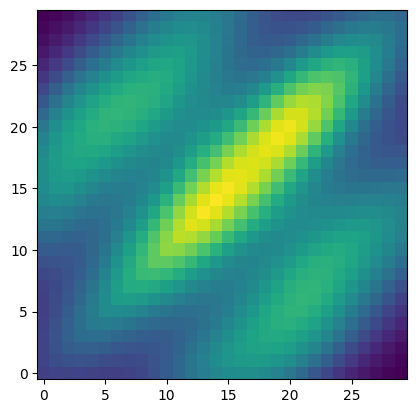

In [71]:
plt.imshow(po_rate_bl[1,:,:], origin='lower')

In [6]:
idata = az.from_numpyro(mcmc)
idata

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data

In [7]:
az.summary(idata, var_names=['X_a/omega', 'X_a/omega'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"X_a/omega[0, 0, 0]",-0.870,0.692,-2.207,0.440,0.036,0.026,364.0,502.0,1.01
"X_a/omega[0, 0, 1]",-0.602,0.706,-1.975,0.682,0.040,0.028,315.0,614.0,1.02
"X_a/omega[0, 0, 2]",-0.640,0.727,-1.940,0.749,0.039,0.028,348.0,546.0,1.01
"X_a/omega[0, 0, 3]",-0.658,0.689,-2.041,0.556,0.035,0.025,396.0,920.0,1.01
"X_a/omega[0, 0, 4]",-0.772,0.708,-2.086,0.533,0.041,0.029,308.0,475.0,1.03
...,...,...,...,...,...,...,...,...,...
"X_a/omega[1, 29, 25]",-0.644,0.672,-1.911,0.597,0.032,0.023,435.0,690.0,1.00
"X_a/omega[1, 29, 26]",-0.708,0.708,-2.059,0.581,0.037,0.026,359.0,686.0,1.01
"X_a/omega[1, 29, 27]",-0.862,0.713,-2.251,0.374,0.041,0.029,309.0,656.0,1.01
"X_a/omega[1, 29, 28]",-0.642,0.691,-1.898,0.630,0.044,0.031,252.0,417.0,1.01


In [8]:
po_b0 = idata.posterior['baseline']
po_f = idata.posterior['f']

po_baseline_rate = (po_b0 + po_f).values.reshape((4, 500, 30, 30), order='F')
po_log_delta = idata.posterior['X_a/log_delta']
po_rate = po_baseline_rate[:,:,None,:,:] + po_log_delta
po_rate = po_rate.quantile([0.025, 0.5, 0.975], dim=['chain', 'draw'])
po_median = np.exp(po_rate.values[1,:,:,:])

In [9]:
idx = np.array([[k, i, j] for k in range(2) for i in range(30) for j in range(30)])

df = pd.DataFrame({
  'subgroup': idx[:,0],
  'a': idx[:,1],
  'b': idx[:,2],
  'rate': po_median[idx[:,0], idx[:,1], idx[:,2]]
})

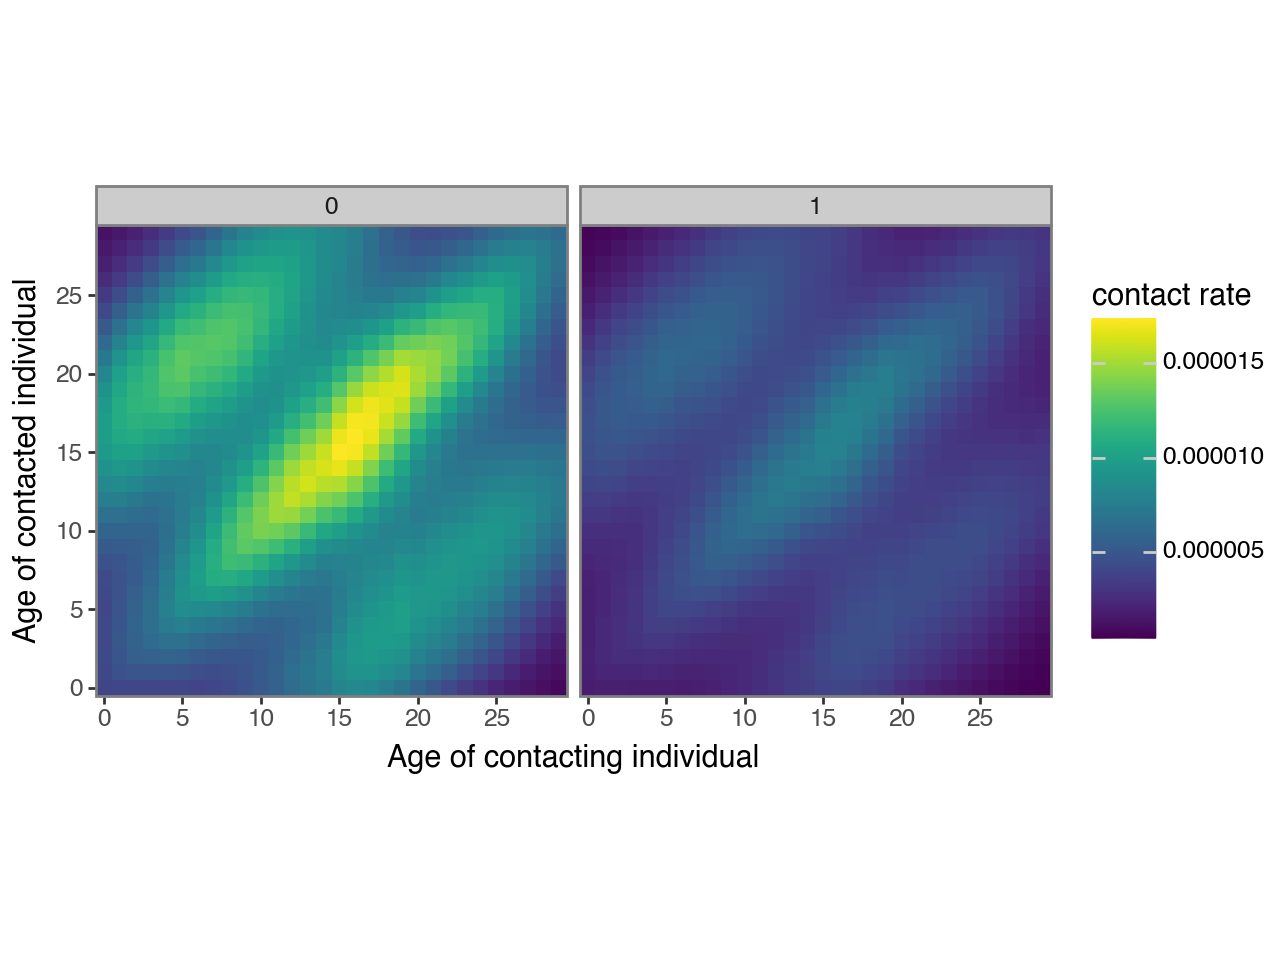

In [10]:
(
  ggplot(df, aes(x='a', y='b', fill='rate')) +
  geom_tile() +
  facet_wrap('subgroup') + 
  scale_x_continuous(breaks=range(0, 30, 5), expand=(0,0)) + 
  scale_y_continuous(breaks=range(0, 30, 5), expand=(0,0)) +
  labs(x='Age of contacting individual', y='Age of contacted individual', fill='contact rate') +
  theme(aspect_ratio=1)
)